# GAN inference & resolution check

Load a **trained GAN generator**, run it on real validation events, and visualize:

- **LR input** — `(3, 64, 64)`
- **GAN output (super-resolved)** — `(3, 125, 125)`
- **HR target** — `(3, 125, 125)`

Jet images are sparse (~2-3% nonzero), so everything is shown in `log1p` energy scale.
The model and data pipeline are imported from `train_srgan.py` so this stays in sync with training.

In [3]:
import sys
from pathlib import Path

# Run from repo root regardless of where the notebook kernel starts
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt

from train_srgan import (
    Generator,
    ChannelStats,
    ParquetJetSRDataset,
    discover_parquet_files,
    split_files,
    normalize,
    denormalize,
)

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("root:", ROOT)
print("device:", device)

ImportError: cannot import name 'ParquetJetSRDataset' from 'train_srgan' (/Users/rajveerrathod/Work/Google_Summer_of_code/task/SRGAN/train_srgan.py)

## 1. Load the trained checkpoint

`final_run` (epoch 17, with the energy/physics loss) is the most-trained baseline.
Swap `CKPT` to any other run under `outputs/*/checkpoints/best.pt` to compare.

In [2]:
CKPT = ROOT / "outputs/final_run/checkpoints/best.pt"

ckpt = torch.load(CKPT, map_location=device, weights_only=False)
print("checkpoint:", CKPT.relative_to(ROOT))
print("trained epoch:", ckpt["epoch"])

# Channel-wise log1p normalization stats saved with the model
stats = ChannelStats(
    mean=torch.tensor(ckpt["stats"]["mean"]),
    std=torch.tensor(ckpt["stats"]["std"]),
)

generator = Generator().to(device)
generator.load_state_dict(ckpt["generator"])
generator.eval()
n_params = sum(p.numel() for p in generator.parameters())
print(f"generator params: {n_params:,}")

checkpoint: outputs/final_run/checkpoints/best.pt
trained epoch: 17
generator params: 648,835


## 2. Grab a batch of real validation events

Same file split as training: last file → validation.

In [3]:
files = discover_parquet_files(ROOT / "datasets")
train_files, val_files = split_files(files, val_ratio=0.33)
print("val files:", [f.name for f in val_files])

val_ds = ParquetJetSRDataset(
    val_files, batch_size=16, shuffle_files=False, shuffle_batches=False, batch_buffer_size=1
)
batch = next(iter(val_ds))
print("LR batch (input) :", tuple(batch["lr"].shape))
print("HR batch (target):", tuple(batch["hr"].shape))

val files: ['QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet']
LR batch (input) : (16, 3, 64, 64)
HR batch (target): (16, 3, 125, 125)


## 3. Run the generator

Pipeline: `normalize (log1p + standardize)` → `generator` → `denormalize (expm1)` back to raw energy.

In [4]:
with torch.no_grad():
    lr_n = normalize(batch["lr"].to(device), stats)
    hr_n = normalize(batch["hr"].to(device), stats)
    fake_n = generator(lr_n, hr_n.shape[-2:])  # target_size = 125x125

    lr_raw = denormalize(lr_n, stats).cpu().numpy()
    fake_raw = denormalize(fake_n, stats).cpu().numpy()
    hr_raw = denormalize(hr_n, stats).cpu().numpy()

print("INPUT  (LR) resolution:", lr_raw.shape[1:], "<- low resolution")
print("OUTPUT (SR) resolution:", fake_raw.shape[1:], "<- generated high resolution")
print("TARGET (HR) resolution:", hr_raw.shape[1:], "<- true high resolution")
scale = hr_raw.shape[-1] / lr_raw.shape[-1]
print(f"upscale factor: {lr_raw.shape[-1]} -> {hr_raw.shape[-1]}  (x{scale:.2f})")

INPUT  (LR) resolution: (3, 64, 64) <- low resolution
OUTPUT (SR) resolution: (3, 125, 125) <- generated high resolution
TARGET (HR) resolution: (3, 125, 125) <- true high resolution
upscale factor: 64 -> 125  (x1.95)


## 4. Visualize: LR input vs GAN output vs HR target

One row per detector channel (ECAL / HCAL / Tracks). Image titles show total energy `E` per channel
and the response (output/target) is printed below — for a good model it should be ~1.0.

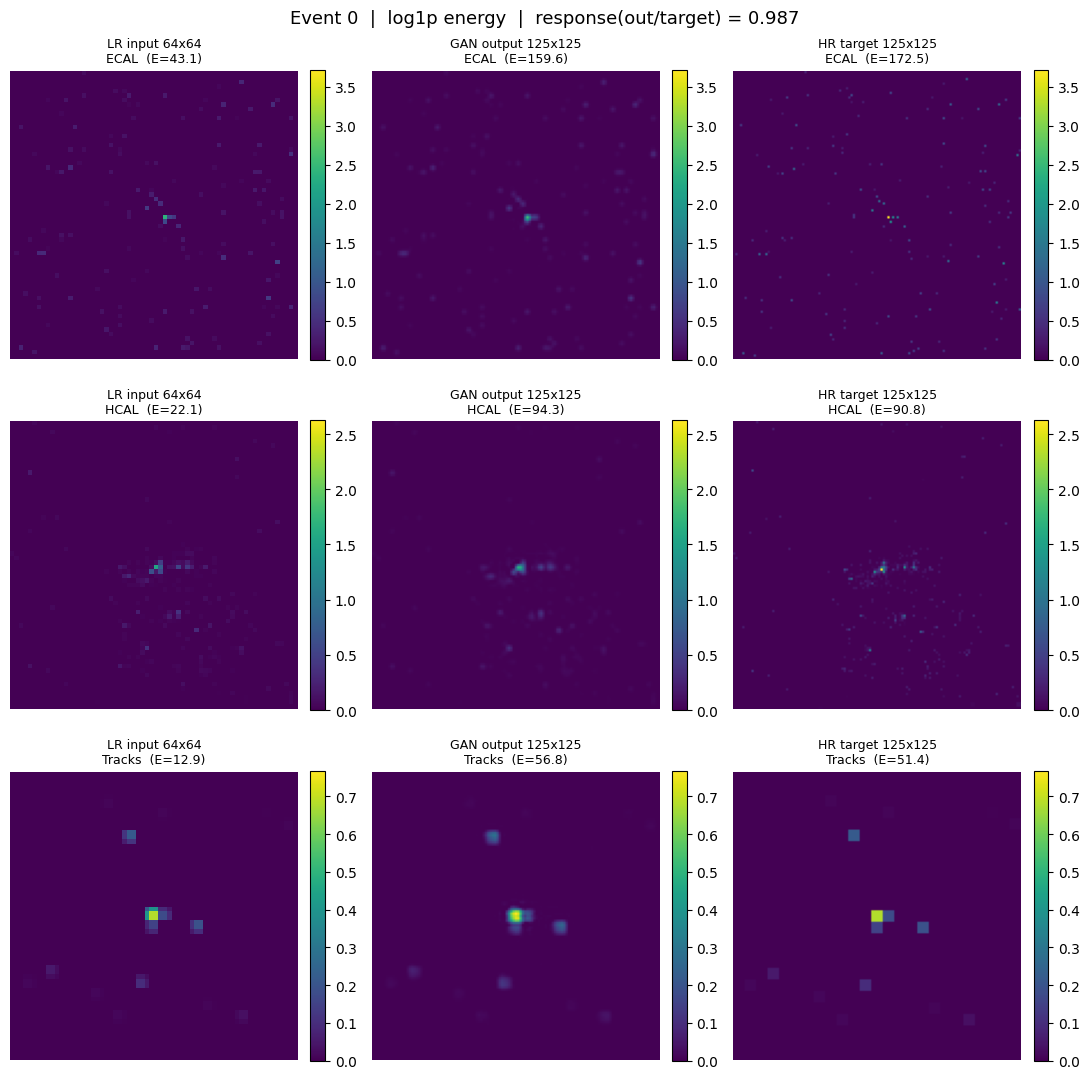

In [5]:
CHANNELS = ("ECAL", "HCAL", "Tracks")

def show_event(idx: int):
    lr, fake, hr = lr_raw[idx], fake_raw[idx], hr_raw[idx]
    fig, axes = plt.subplots(3, 3, figsize=(11, 11))
    cols = [
        (f"LR input {lr.shape[1]}x{lr.shape[2]}", lr),
        (f"GAN output {fake.shape[1]}x{fake.shape[2]}", fake),
        (f"HR target {hr.shape[1]}x{hr.shape[2]}", hr),
    ]
    for r, ch in enumerate(CHANNELS):
        vmax = max(np.log1p(fake[r]).max(), np.log1p(hr[r]).max(), 1e-6)
        for c, (title, img) in enumerate(cols):
            ax = axes[r, c]
            im = ax.imshow(np.log1p(img[r]), cmap="viridis", vmin=0, vmax=vmax)
            ax.set_title(f"{title}\n{ch}  (E={img[r].sum():.1f})", fontsize=9)
            ax.axis("off")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    resp = fake.sum() / max(hr.sum(), 1e-6)
    fig.suptitle(
        f"Event {idx}  |  log1p energy  |  response(out/target) = {resp:.3f}", fontsize=13
    )
    fig.tight_layout()
    return fig

fig = show_event(0)
plt.show()

## 5. Browse a few more events

Change the index to inspect different jets in the batch.

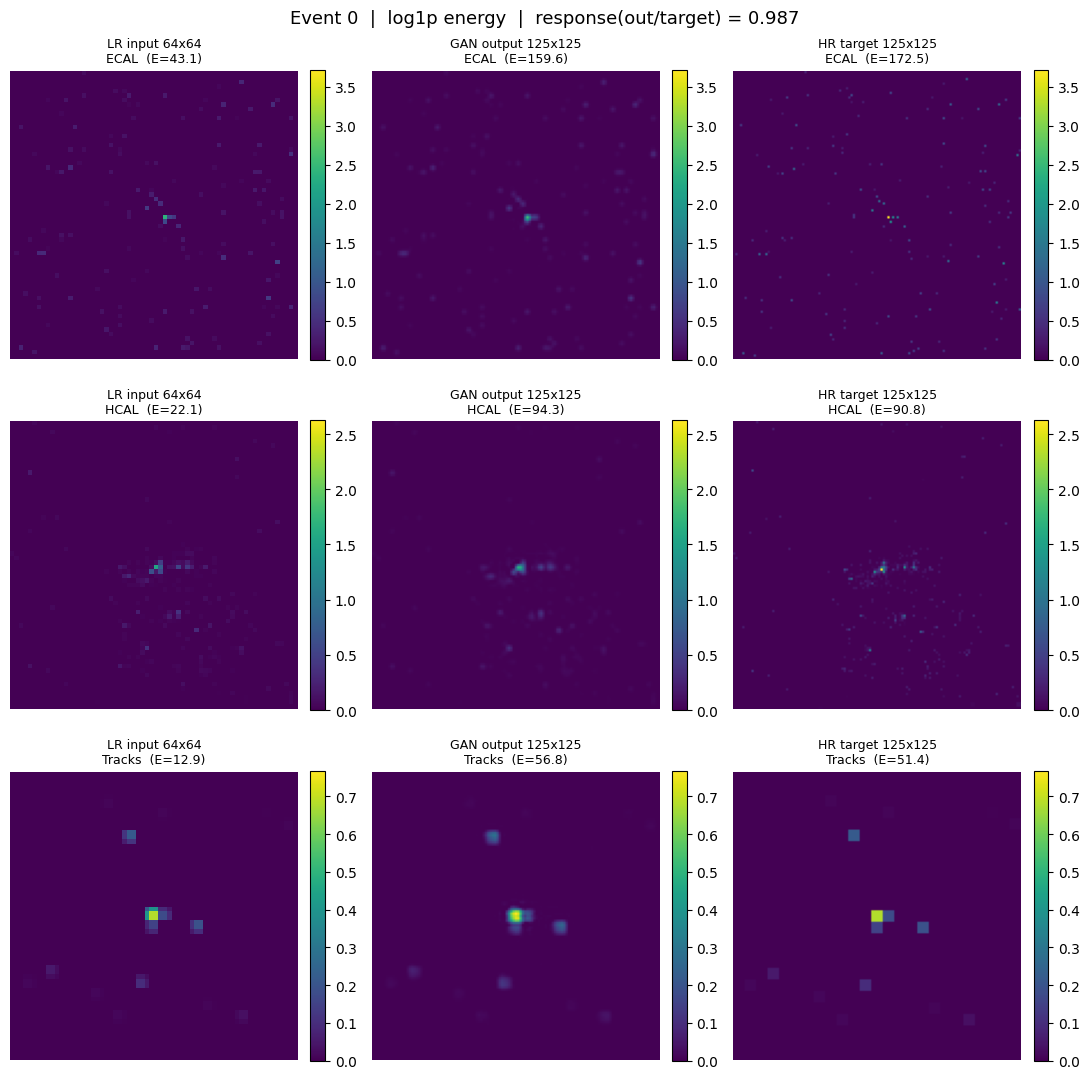

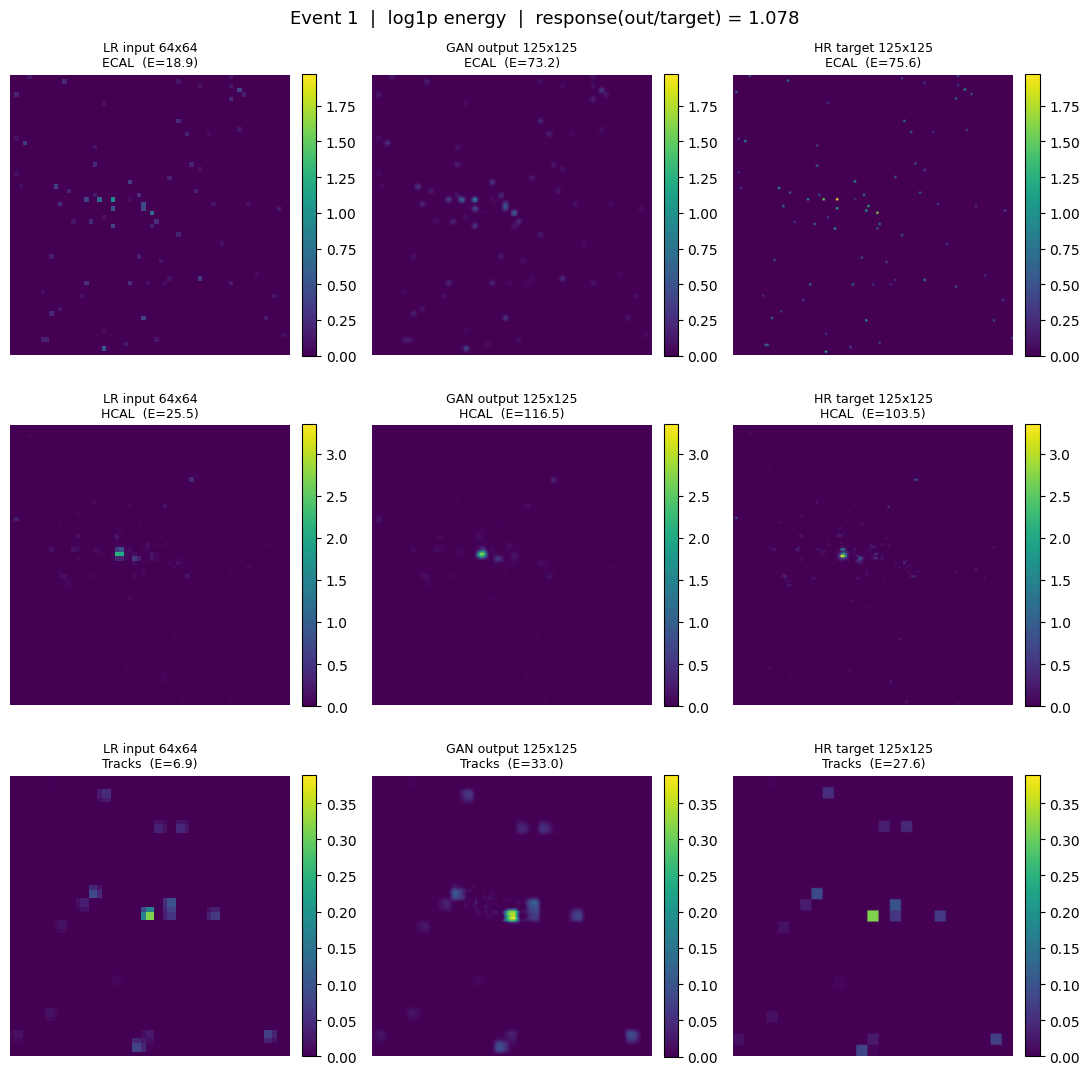

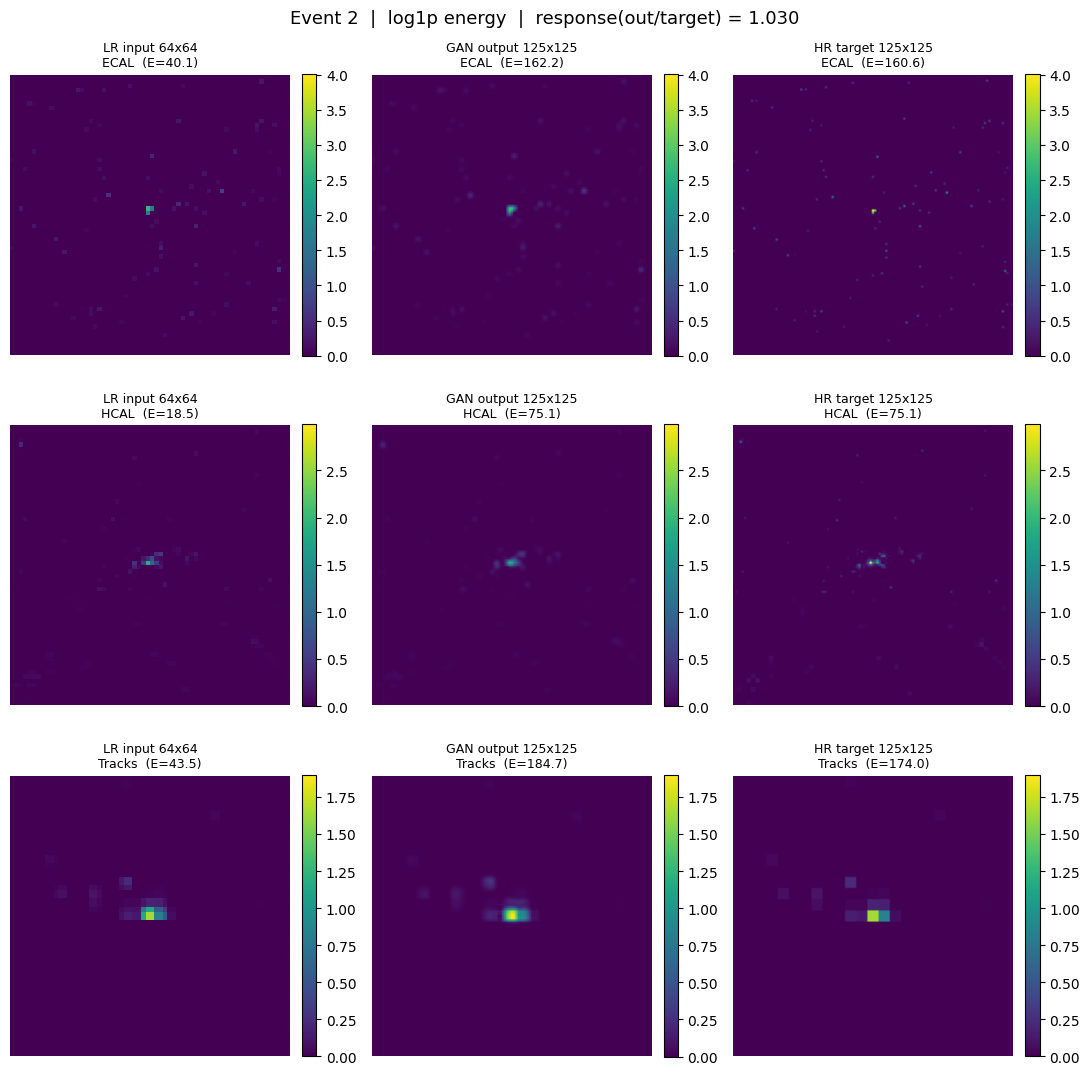

In [6]:
for idx in range(3):
    show_event(idx)
    plt.show()

## 6. Should the super-resolution be an *exact* match to the HR target?

**No — and it cannot be.** Single-image super-resolution is an *ill-posed, one-to-many* problem:

- Input is `64x64 = 4,096` pixels; target is `125x125 = 15,625` pixels per channel.
- The network must **invent ~11,500 pixels of detail** that are not present in the LR input.
- The LR has already discarded information and holds only a fraction of the HR energy
  (e.g. ECAL `43.1` vs `172.5`). Many plausible HR images are consistent with one LR image,
  so the model predicts the **expected** energy deposit, not exact pixel values it cannot know.

**The expected, correct difference:** the GAN output is slightly *smoother / blurrier* than the
true HR, which is sharper and grainier. This is the signature of the L1-dominated loss
(`lambda_l1=50`): L1 averages over uncertainty. It is **not a bug**.

**How to actually judge quality** — match *distributions* over many events, not single pixels:

| Criterion | What good looks like |
|---|---|
| Energy **response** (Sum_pred / Sum_true) | mean ~ 1.0, small spread |
| Per-channel **energy correlation** r | close to 1.0 |
| Hot-spot **location & morphology** | matches HR (visual) |
| Pixel **L1** (normalized) | low, but never exactly 0 |

The cells below compute these over a batch of validation events.

In [7]:
# Run the generator over many validation events and collect physics metrics.
MAX_EVENTS = 200

analysis_ds = ParquetJetSRDataset(
    val_files, batch_size=16, shuffle_files=False, shuffle_batches=False, batch_buffer_size=1
)

response, e_pred, e_true, l1_norm = [], [], [], []
seen = 0
with torch.no_grad():
    for b in analysis_ds:
        lrn = normalize(b["lr"].to(device), stats)
        hrn = normalize(b["hr"].to(device), stats)
        fkn = generator(lrn, hrn.shape[-2:])
        l1_norm.append(torch.nn.functional.l1_loss(fkn, hrn).item())
        fk = denormalize(fkn, stats).cpu().numpy()
        hr = denormalize(hrn, stats).cpu().numpy()
        ep = fk.reshape(fk.shape[0], -1).sum(1)   # total energy per event (pred)
        et = hr.reshape(hr.shape[0], -1).sum(1)   # total energy per event (true)
        response.extend((ep / np.clip(et, 1e-6, None)).tolist())
        e_pred.append(fk.sum(axis=(2, 3)))        # per-channel energy
        e_true.append(hr.sum(axis=(2, 3)))
        seen += fk.shape[0]
        if seen >= MAX_EVENTS:
            break

response = np.array(response)
e_pred = np.concatenate(e_pred)
e_true = np.concatenate(e_true)

print(f"events analyzed   : {len(response)}")
print(f"energy response   : mean={response.mean():.4f}  std={response.std():.4f}  median={np.median(response):.4f}")
print(f"pixel L1 (norm)   : {np.mean(l1_norm):.5f}  (never 0 -- exact match is not the goal)")
for i, ch in enumerate(CHANNELS):
    r = np.corrcoef(e_pred[:, i], e_true[:, i])[0, 1]
    print(f"{ch:7s} energy corr: r={r:.4f}")

events analyzed   : 208
energy response   : mean=0.9965  std=0.0316  median=0.9985
pixel L1 (norm)   : 0.09456  (never 0 -- exact match is not the goal)
ECAL    energy corr: r=0.9869
HCAL    energy corr: r=0.9960
Tracks  energy corr: r=0.9994


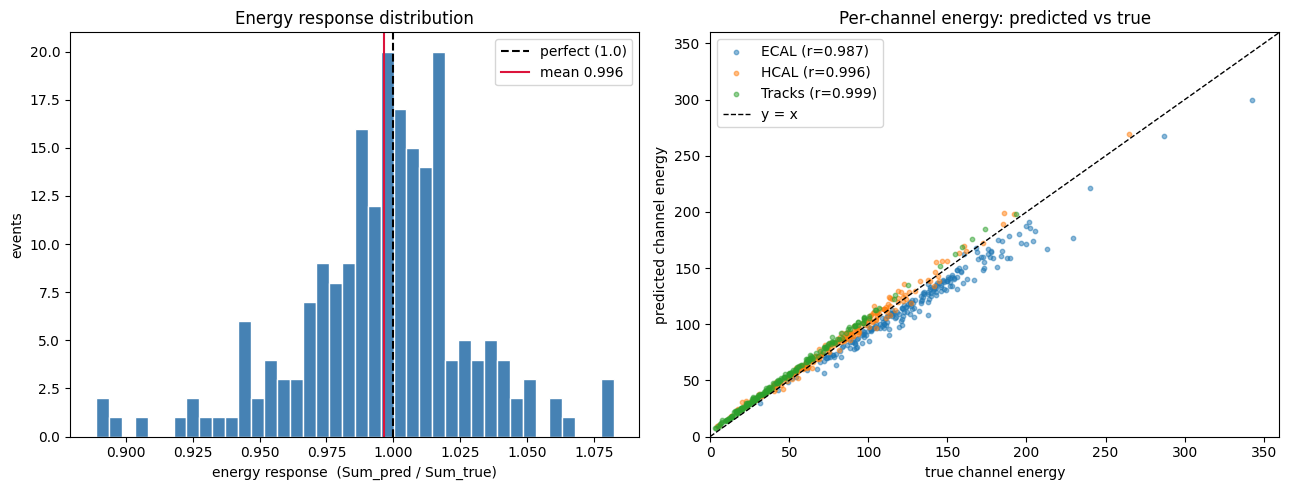

In [8]:
# Left: energy-response distribution (should peak at 1.0).
# Right: per-channel predicted vs true energy (points should hug the diagonal).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.hist(response, bins=40, color="steelblue", edgecolor="white")
ax1.axvline(1.0, color="k", ls="--", label="perfect (1.0)")
ax1.axvline(response.mean(), color="crimson", ls="-", label=f"mean {response.mean():.3f}")
ax1.set_xlabel("energy response  (Sum_pred / Sum_true)")
ax1.set_ylabel("events")
ax1.set_title("Energy response distribution")
ax1.legend()

colors = ["tab:blue", "tab:orange", "tab:green"]
lim = max(e_true.max(), e_pred.max()) * 1.05
for i, ch in enumerate(CHANNELS):
    r = np.corrcoef(e_pred[:, i], e_true[:, i])[0, 1]
    ax2.scatter(e_true[:, i], e_pred[:, i], s=10, alpha=0.5, color=colors[i], label=f"{ch} (r={r:.3f})")
ax2.plot([0, lim], [0, lim], "k--", lw=1, label="y = x")
ax2.set_xlim(0, lim); ax2.set_ylim(0, lim)
ax2.set_xlabel("true channel energy")
ax2.set_ylabel("predicted channel energy")
ax2.set_title("Per-channel energy: predicted vs true")
ax2.legend()

fig.tight_layout()
plt.show()

## 7. (Optional) save a figure to reports/

saved /Users/rajveerrathod/Work/Google_Summer_of_code/task/reports/gan_inference_event0.png


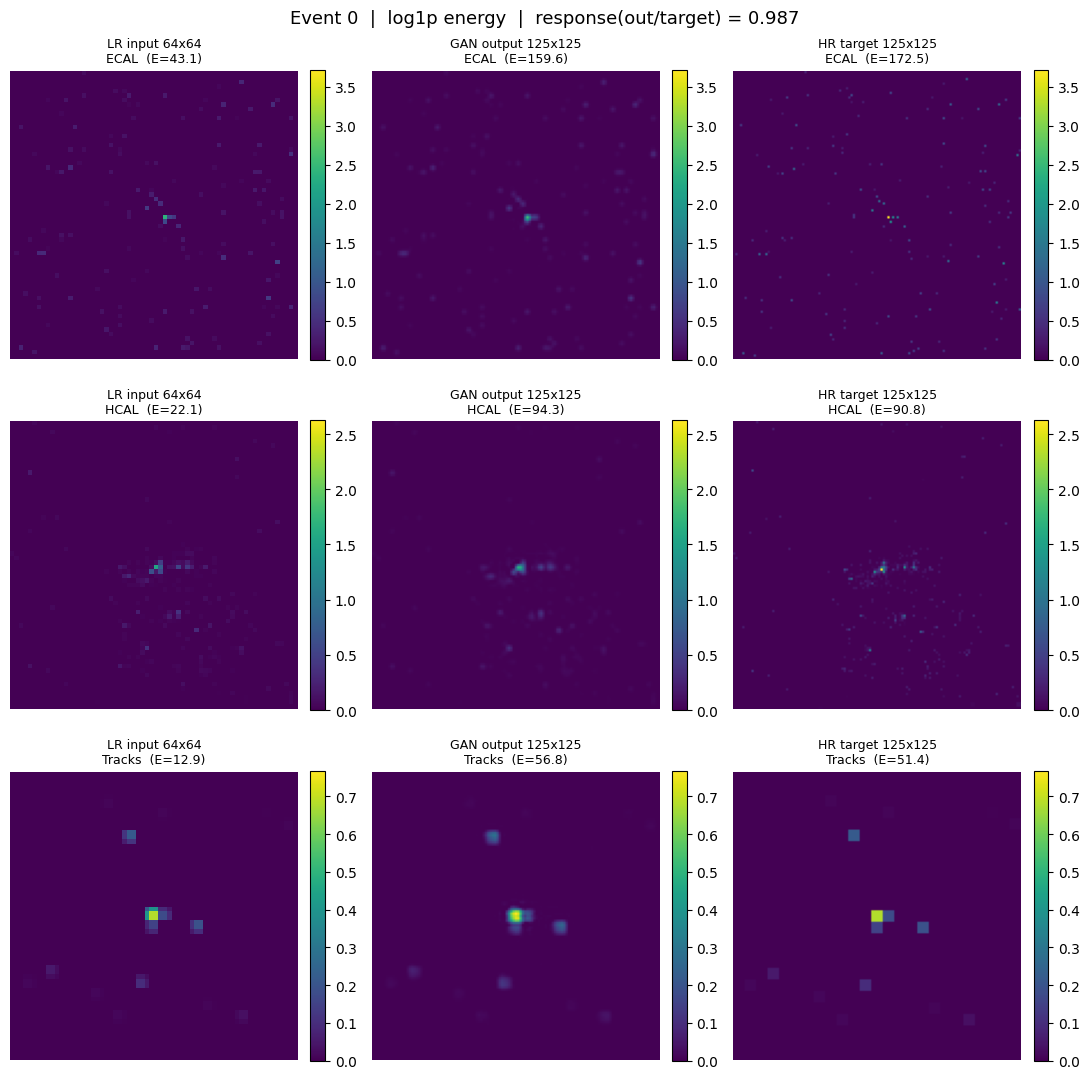

In [9]:
out = ROOT / "reports" / "gan_inference_event0.png"
out.parent.mkdir(parents=True, exist_ok=True)
show_event(0).savefig(out, dpi=130, bbox_inches="tight")
print("saved", out)